In [2]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X,y = make_regression(n_samples=5, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

In [4]:
y.ndim

1

In [5]:
X.ndim

2

In [6]:
X

array([[ 1.34510171],
       [-0.71239066],
       [-0.04450308],
       [ 0.75376638],
       [ 0.45181234]])

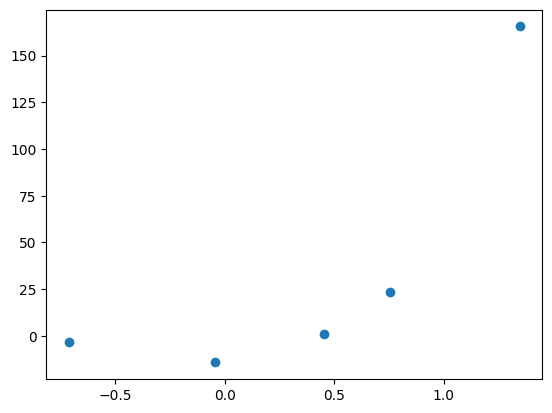

In [7]:
plt.scatter(X,y)

### 1st find the best fit line (coff. & intercept value) using Ordinary least Square (OLS) method

In [8]:
#Calculate the best fit line using OLS methd
from sklearn.linear_model import LinearRegression

In [9]:
ols_lr = LinearRegression()

In [10]:
ols_lr.fit(X,y)

LinearRegression()

In [11]:
ols_lr.coef_

array([74.25418669])

In [12]:
ols_lr.intercept_

np.float64(7.793295813898464)

In [13]:
ols_y_pred = ols_lr.predict(X)

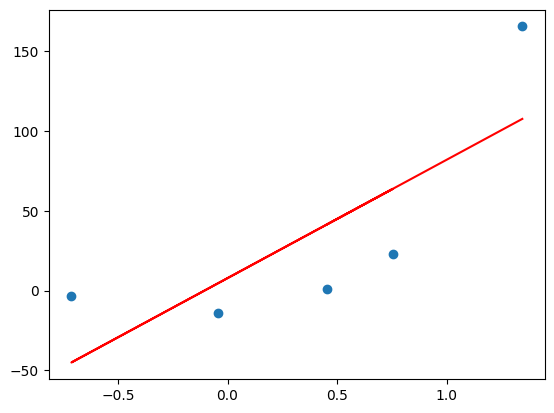

In [14]:
plt.scatter(X, y)
plt.plot(X, ols_y_pred, color='red')

#### Here we will calculate the Gradient descent by assuming that we have already known one of the parameters.
like for calculation of m we have assumed that we have already known the value of b.
and for calculation of b we have assumed that we have already known the value of m. which makes the understaing easier.

#### Process:

- Let's assume m is constant (here 78.25)
- let's choose any value of b (it can be -ve, 0 or +ve)
- calculate y_pred by using formula y_pred = m * X + b for each value of X
- Find the error between y_pred and y_true for each value of X using derivative (w.r.t b) of formula error = (y_true - y_pred) ^ 2

In [15]:
m=78.25

In [16]:
#1st Iterration
b = 100
y_pred = ((78.25 * X) + 100).reshape(5)

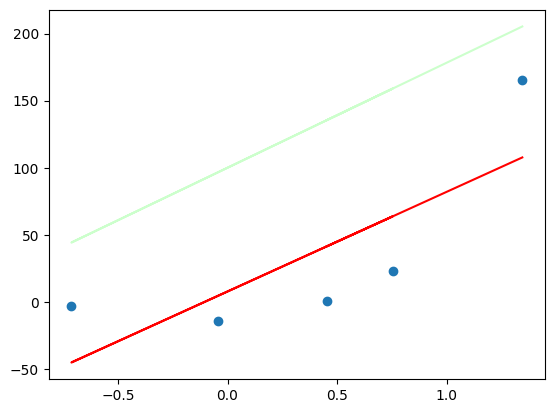

In [17]:
plt.scatter(X, y)
plt.plot(X, ols_y_pred, color='red', label="OLS")
plt.plot(X, y_pred, color='#ccffcc', label="b=100")

In [18]:
error = -2 * np.sum(y - m * X.ravel() - b)
print(error)

936.4023152838473


In [19]:
#let's assume learning rate is 0.1
lr = 0.1
step_size = 0.1 * error
print(step_size)

93.64023152838473


In [20]:
#Update the value of b untill we do not reach reach the best fit line or till no. of iterations is reached (epocks)
b = b - step_size
print(b)

6.3597684716152685


In [21]:
b

np.float64(6.3597684716152685)

In [22]:

y_pred1 = ((78.25 * X) + b).reshape(5)

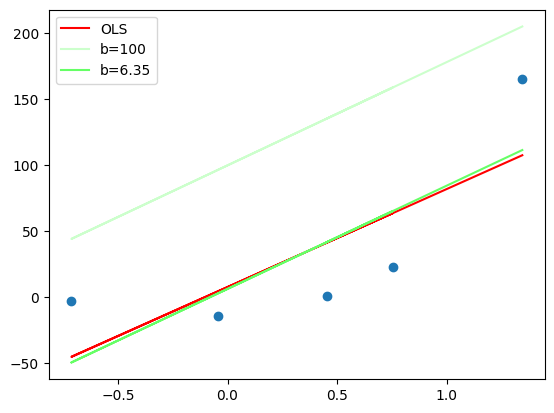

In [23]:
plt.scatter(X, y)
plt.plot(X, ols_y_pred, color='red', label="OLS")
plt.plot(X, y_pred, color='#ccffcc', label="b=100")
plt.plot(X, y_pred1, color='#66ff66', label="b=6.35")
plt.legend()

In [24]:
#2nd Iterration

In [25]:
b #6.3597684716152685

np.float64(6.3597684716152685)

In [26]:
#Find Error
error = -2 * np.sum(y - m * X.ravel() - b)
print(error)

-0.0


In [27]:
#Find Step Size
step_size = 0.1 * error
print(step_size)

-0.0


In [28]:
#Find new value of b
b = b - step_size
print(b)

6.3597684716152685


In [29]:
print(b)

6.3597684716152685


In [30]:
y_pred2 = ((78.25 * X) + b).reshape(5)

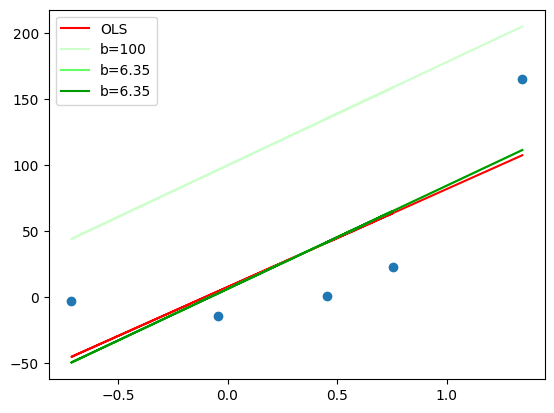

In [31]:
plt.scatter(X, y)
plt.plot(X, ols_y_pred, color='red', label="OLS")
plt.plot(X, y_pred, color='#ccffcc', label="b=100")
plt.plot(X, y_pred1, color='#66ff66', label="b=6.35")
plt.plot(X, y_pred2, color='#009900', label="b=6.35")

plt.legend()

- In above iterrations we Fixed the value of of "m" (taken from LinearRegression Model) and taken the random value of b (100) initially.
- after each iterration we each iterration we update the value of "b" and iterrate it untill itconversed to calculated value of "b" (7.793)

In [39]:
class gdReggOneVar:

    def __init__(self, b, m, learning_rate, epochs):
        self.m = m #78.25
        self.b = b
        self.lr = learning_rate
        self.epochs = epochs
    
    def fit(self, X, y):
        #calculate and update the "b" using GD
        for i in range(self.epochs):
            errors =  -2 * np.sum(y - self.m * X.ravel() - self.b)

            self.b = self.b - self.lr * errors
            print(self.m, self.b)

    def predict(self, X):
        return self.m*X + self.b



In [40]:
gd = gdReggOneVar(m=78.25, b=100, learning_rate=0.1, epochs=10)

In [41]:
gd.fit(X,y)

78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685
78.25 6.3597684716152685


In [49]:
gd = gdReggOneVar(m=78.25, b=100, learning_rate=0.01, epochs=100)

In [48]:
gd.fit(X,y)

78.25 53.179884235807634
78.25 29.76982635371145
78.25 18.06479741266336
78.25 12.212282942139314
78.25 9.28602570687729
78.25 7.822897089246278
78.25 7.091332780430774
78.25 6.72555062602302
78.25 6.5426595488191435
78.25 6.451214010217205
78.25 6.405491240916235
78.25 6.382629856265752
78.25 6.371199163940509
78.25 6.365483817777887
78.25 6.362626144696579
78.25 6.3611973081559245
78.25 6.360482889885596
78.25 6.360125680750431
78.25 6.359947076182851
78.25 6.359857773899059
78.25 6.3598131227571635
78.25 6.359790797186215
78.25 6.359779634400741
78.25 6.359774053008004
78.25 6.359771262311636
78.25 6.359769866963452
78.25 6.3597691692893585
78.25 6.359768820452313
78.25 6.359768646033791
78.25 6.359768558824528
78.25 6.359768515219899
78.25 6.359768493417582
78.25 6.359768482516424
78.25 6.359768477065846
78.25 6.359768474340555
78.25 6.35976847297791
78.25 6.3597684722965875
78.25 6.3597684719559275
78.25 6.359768471785598
78.25 6.359768471700432
78.25 6.3597684716578495
78.25 6.35

#### Let's Calculate both the parameter ("m" & "b") in single class

In [63]:
class gdReggBothVar:

    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    
    def fit(self, X, y):
        #calculate and update the "b" using GD
        for i in range(self.epochs):
            errors_b =  -2 * np.sum(y - self.m * X.ravel() - self.b)
            errors_m = -2 * np.sum((y- self.m * X.ravel() - self.b) * X.ravel())

            self.b = self.b - self.lr * errors_b
            self.m = self.m - self.lr * errors_m
            print(self.m, self.b)

    def predict(self, X):
        return self.m*X + self.b



In [69]:
gd = gdReggBothVar(learning_rate=0.01, epochs=200)

In [70]:
gd.fit(X,y)

102.99303204803701 -108.144320361017
105.37569899631632 -97.58158590667124
107.23211992130477 -88.1606048227146
108.6357894101261 -79.748322309911
109.65088506172943 -72.22762572118467
110.33341541398785 -65.4954160926174
110.73222771891871 -59.46091370407305
110.88989262641739 -54.04416923843485
110.84348076221256 -49.174755563597195
110.62524436328418 -44.79061819656214
110.2632155330762 -40.83706517529696
109.78173127255396 -37.26587940625063
109.201894207841 -34.0345386129932
108.54197685004254 -31.105529818933054
107.81777626966255 -28.44574688488036
107.04292523071504 -26.02596101705906
106.22916509412747 -23.820355386482195
105.38658515396003 -21.80611607699951
104.52383250244893 -19.9630725249028
103.64829602137345 -18.273381443633106
102.76626765935771 -16.72124895684249
101.88308377007846 -15.29268630409116
101.003248948488 -13.975295046586783
100.13054450538739 -12.758078195065247
99.26812346000729 -11.631274116488214
98.41859370128043 -10.586210457999481
97.58409076736987 -

In [71]:
X

array([[ 1.34510171],
       [-0.71239066],
       [-0.04450308],
       [ 0.75376638],
       [ 0.45181234]])

In [72]:
y

array([165.63483897,  -3.12090448, -14.3265676 ,  23.23552152,
         0.73976209])

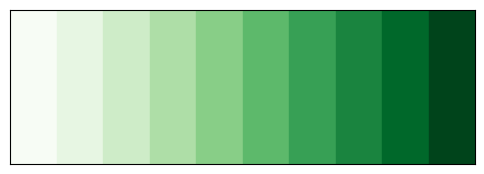

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Generate values from 0 to 1
values = np.linspace(0, 1, 10)  # 10 shades of green

# Get colors from Greens colormap
colors = plt.cm.Greens(values)

# Plot color gradient
fig, ax = plt.subplots(figsize=(6, 2))
for i, color in enumerate(colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))

ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
plt.show()
